# 📘 Central Limit Theorem (CLT) — Simulation Study

This project investigates, through simulations, how the distribution of sample means behaves.

## Reproducibility seed

The study is fully reproducible — the seed below initializes the random generator.

In [1]:
# Reproducibility seed — initializes the random generator so the entire study can be reproduced.
RA = 26000001

## Libraries

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


## Generating the populations

Two custom populations are generated below — one Normal and one Exponential, each with 10,000 values.

In [3]:
random.seed(RA)

pop_normal = [random.gauss(50, 10) for i in range(10000)]

pop_exponencial = [random.expovariate(1/50) for i in range(10000)]



## Visualizing the populations

The histograms of the two populations are shown below.

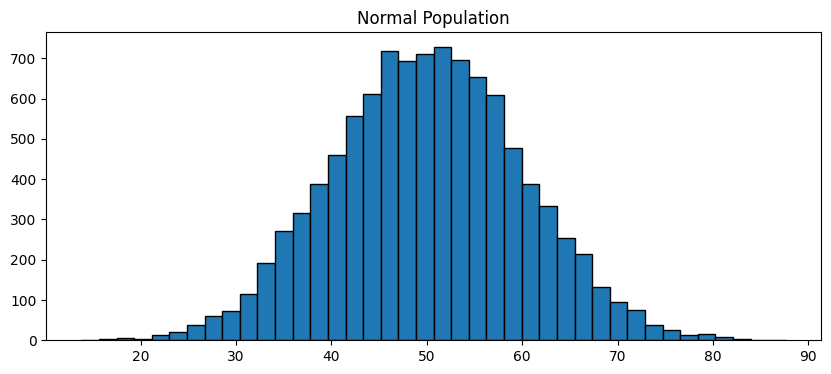

In [4]:
plt.figure(figsize=(10,4))
plt.hist(pop_normal, bins=40, edgecolor="black")
plt.title("Normal Population")
plt.show()

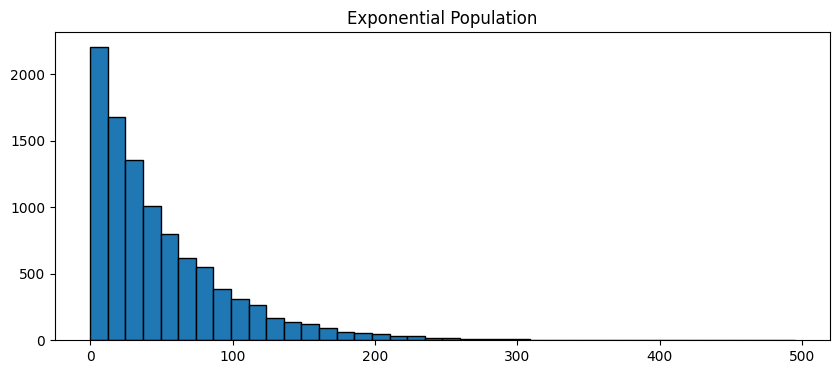

In [5]:
plt.figure(figsize=(10,4))
plt.hist(pop_exponencial, bins=40, edgecolor="black")
plt.title("Exponential Population")
plt.show()

## Simulating the sample means

Here I investigate the **Central Limit Theorem (CLT)** through simulations.

For **each population**, I work with:

```python
n_amostras = 1000
tamanhos_n = [16, 25, 36, 100, 400]
```

For **each value of n**, I:

1. draw 1000 samples of size `n`;
2. compute the mean of each sample;
3. store the 1000 means in a list;
4. build histograms of the sample means;
5. compare the observed behavior with what the CLT predicts.

Note: where possible I use density histograms, which makes the comparison with the theoretical normal curve easier.

In [6]:
# General simulation parameters
n_amostras = 1000  # number of samples per simulation
tamanhos_n = [16, 25, 36, 100, 400]


### **Problem 1 — Normal population**

Using the `pop_normal` generated above.

a) Compute the population mean **mu**, to one decimal place.

In [7]:
mu = round(np.mean(pop_normal), 1)
print(f"Normal population mean: mu = {mu}")

Normal population mean: mu = 50.1


b) Compute the population standard deviation **sigma**, to one decimal place.

In [8]:
sigma = round(np.std(pop_normal, ddof=1), 1)
print(f"Normal population standard deviation: sigma = {sigma}")

Normal population standard deviation: sigma = 9.9


c) For each value of `n` in `tamanhos_n`, draw **1000 samples** from the **normal population**, compute the mean of each sample and store the results.

I organize the results in a dictionary where each key is a value of `n` and each value is the list of 1000 sample means.

In [9]:
medias_normal = {}                                                          # empty dictionary to keep everything organized

for n in tamanhos_n:                                                        # go through each value: 16, 25, 36, 100, 400
    lista_de_medias = []                                                        # empty list to hold the 1000 means for this n

    for i in range(n_amostras):                                                 # repeat 1000 times
        amostra = random.choices(pop_normal, k=n)                                   # draw n numbers from the population (with replacement)
        media = np.mean(amostra)                                                    # mean of the n drawn numbers
        lista_de_medias.append(media)                                               # record this mean in the list

    medias_normal[n] = lista_de_medias                                          # store the 1000 means in the dictionary under key n

c-1) Plot the histograms of the sample means **side by side**, one for each value of `n`.

Visually observe:

- the shape of the distribution of the means;
- how the means concentrate around the population mean;
- the reduction in spread as `n` grows.

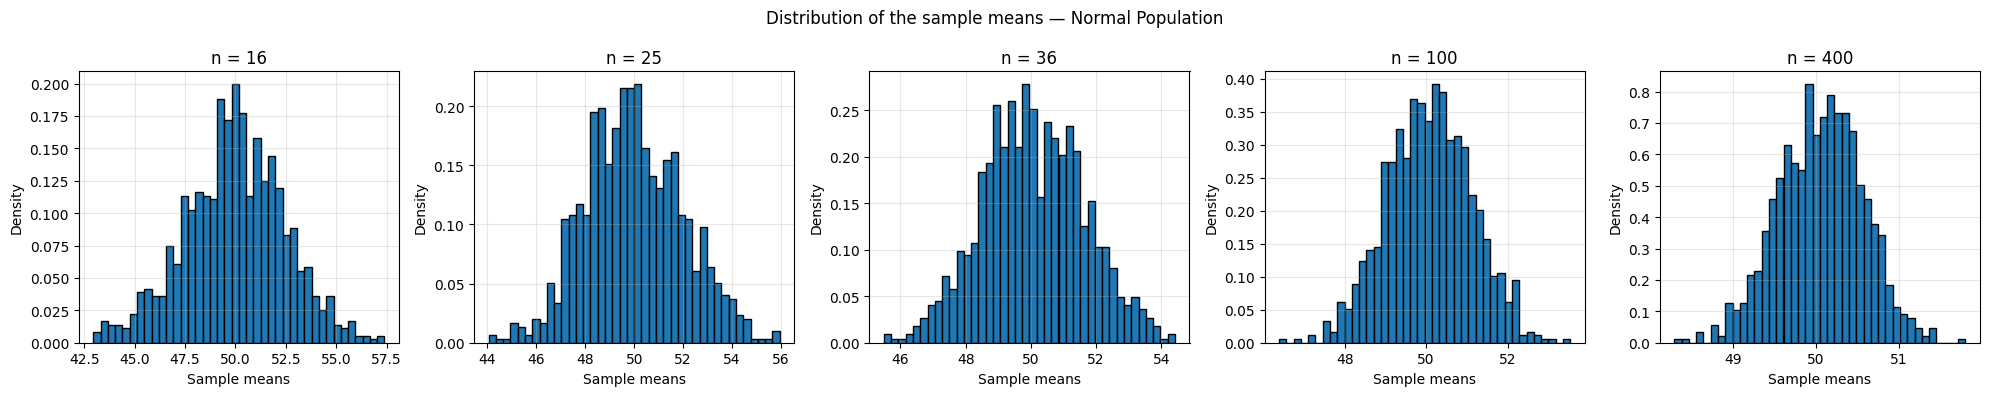

In [10]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    plt.subplot(1, 5, i+1)
    plt.hist(medias_normal[n], bins=40, density=True, edgecolor="black")
    plt.title(f"n = {n}")
    plt.xlabel("Sample means")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribution of the sample means — Normal Population")
plt.tight_layout()
plt.show()

c-2) On each histogram, overlay the **theoretical normal curve** predicted by the CLT.

Use:

- theoretical mean: `mu`;
- theoretical standard deviation of the means: `sigma / sqrt(n)`.

The theoretical normal curve helps compare the simulated distribution of the means with the approximation predicted by the CLT.

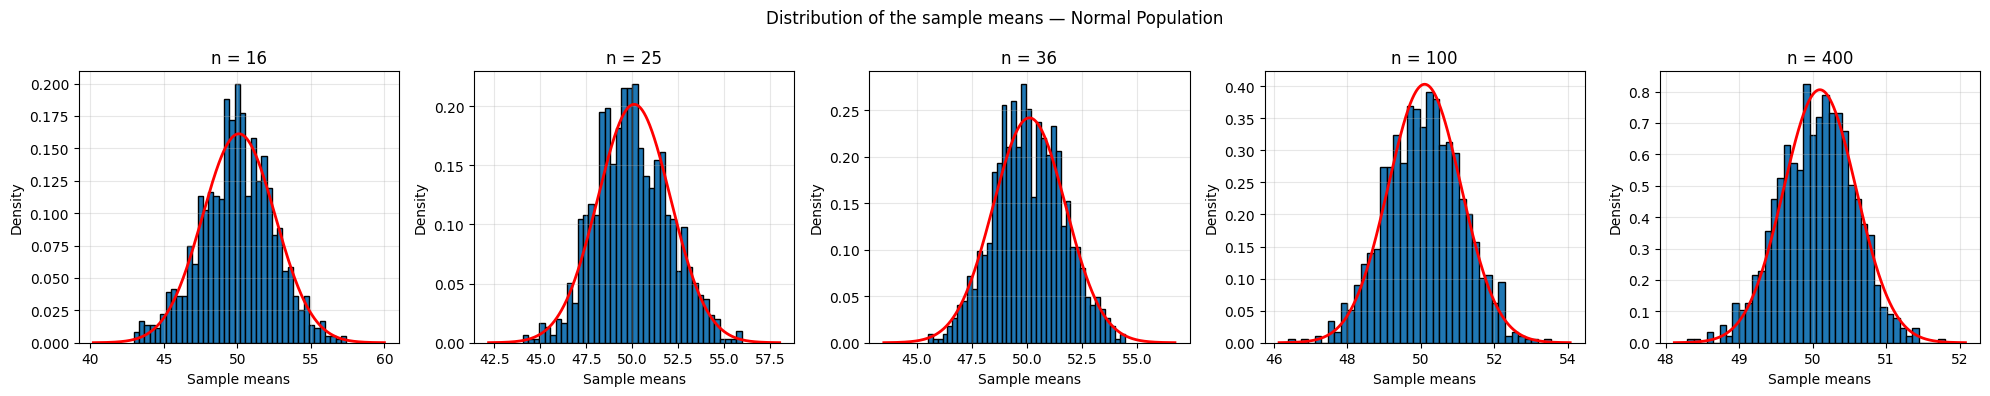

In [11]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    epm_teorico = sigma / np.sqrt(n)

    x = np.linspace(mu - 4*epm_teorico, mu + 4*epm_teorico, 1000)
    y = norm.pdf(x, loc=mu, scale=epm_teorico)

    plt.subplot(1, 5, i+1)
    plt.hist(medias_normal[n], bins=40, density=True, edgecolor="black")
    plt.plot(x, y, color="red", linewidth=2)
    plt.title(f"n = {n}")
    plt.xlabel("Sample means")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribution of the sample means — Normal Population")
plt.tight_layout()
plt.show()

c-3) Does the distribution of the sample means look normal for every value of `n`?

Answer based on the histograms and the comparison with the theoretical normal curve, commenting especially on what happens as `n` grows.

In [12]:
# Yes. For every value of n the distribution of the sample means already looks normal, because the
# source population is itself normal. As n grows, the distribution becomes narrower and more
# concentrated around mu = 50.1, and the theoretical curve (red) fits the histogram bars increasingly well.

c-4) Compute the **mean of the sample means** for each value of `n`, then compare these values with the population mean `mu`.

Build a table with the columns:

| n | mean of means | population mean |
|---|---:|---:|

In [13]:
dados = []

for n in tamanhos_n:
    media_das_medias = round(np.mean(medias_normal[n]), 2)
    dados.append([n, media_das_medias, mu])

tabela = pd.DataFrame(dados, columns=["n", "mean of means", "population mean"])
print(tabela)

     n  mean of means  population mean
0   16          49.95             50.1
1   25          49.98             50.1
2   36          50.08             50.1
3  100          50.07             50.1
4  400          50.05             50.1


c-5) Compute the **observed SEM** and the **theoretical SEM** for each value of `n`.

- observed SEM: standard deviation of the 1000 sample means;
- theoretical SEM: `sigma / sqrt(n)`.

Build a table with the columns:

| n | observed SEM | theoretical SEM |
|---|---:|---:|

This comparison checks whether the simulated behavior is consistent with what the CLT predicts.

In [14]:
dados = []

for n in tamanhos_n:
    epm_obs = round(np.std(medias_normal[n]), 2)
    epm_teo = round(sigma / np.sqrt(n), 2)
    dados.append([n, epm_obs, epm_teo])

tabela_epm = pd.DataFrame(dados, columns=["n", "observed SEM", "theoretical SEM"])
print(tabela_epm)

     n  observed SEM  theoretical SEM
0   16          2.48             2.48
1   25          1.99             1.98
2   36          1.56             1.65
3  100          1.04             0.99
4  400          0.51             0.50


c-6) Plot a chart comparing the **observed SEM** and the **theoretical SEM** as a function of `n`.

The x-axis holds the values of `n`; the y-axis holds the SEM.

The chart shows the drop in the variability of the sample means as the sample size grows.

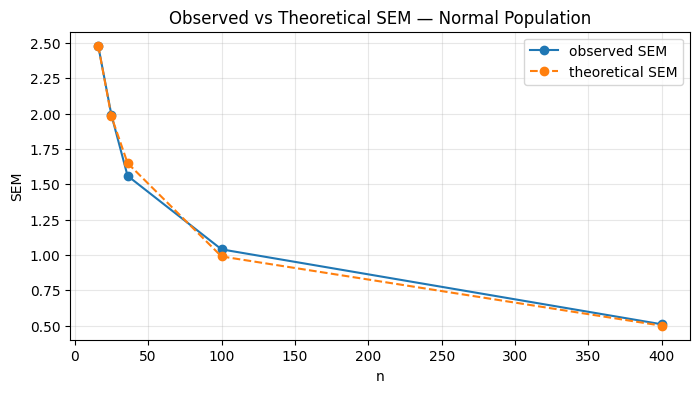

In [15]:
epms_obs = []
epms_teo = []

for n in tamanhos_n:
    epms_obs.append(round(np.std(medias_normal[n]), 2))
    epms_teo.append(round(sigma / np.sqrt(n), 2))

plt.figure(figsize=(8, 4))
plt.plot(tamanhos_n, epms_obs, marker="o", label="observed SEM")
plt.plot(tamanhos_n, epms_teo, marker="o", label="theoretical SEM", linestyle="--")
plt.title("Observed vs Theoretical SEM — Normal Population")
plt.xlabel("n")
plt.ylabel("SEM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

c-7) Does the standard deviation of the sample means approach the value predicted by the CLT?

Explain using the table and the chart of observed vs theoretical SEM.

In [16]:
# Yes. As the table and the chart show, the observed SEM stayed very close to the theoretical SEM for
# every value of n. The largest gap was at n = 36, where the observed SEM was 1.56 and the theoretical
# one was 1.65 — a difference of just 0.09, about 5.5%. This confirms what the CLT predicts: the
# standard deviation of the sample means equals sigma / sqrt(n).

### **Problem 2 — Exponential population**

Using the `pop_exponencial` generated above.

a) Compute the population mean **mu**, to one decimal place.

In [17]:
mu = round(np.mean(pop_exponencial), 1)
print(f"Exponential population mean: mu = {mu}")

Exponential population mean: mu = 49.9


b) Compute the population standard deviation **sigma**, to one decimal place.

In [18]:
sigma = round(np.std(pop_exponencial, ddof=1), 1)
print(f"Exponential population standard deviation: sigma = {sigma}")

Exponential population standard deviation: sigma = 49.5


c) For each value of `n` in `tamanhos_n`, draw **1000 samples** from the **exponential population**, compute the mean of each sample and store the results.

I organize the results in a dictionary where each key is a value of `n` and each value is the list of 1000 sample means.

In [19]:
medias_exponenciais = {}                                                          # empty dictionary to keep everything organized

for n in tamanhos_n:                                                        # go through each value: 16, 25, 36, 100, 400
    lista_de_medias_exp = []                                                        # empty list to hold the 1000 means for this n

    for i in range(n_amostras):                                                 # repeat 1000 times
        amostra = random.choices(pop_exponencial, k=n)                                   # draw n numbers from the population (with replacement)
        media = np.mean(amostra)                                                    # mean of the n drawn numbers
        lista_de_medias_exp.append(media)                                               # record this mean in the list

    medias_exponenciais[n] = lista_de_medias_exp                                          # store the 1000 means in the dictionary under key n

c-1) Plot the histograms of the sample means **side by side**, one for each value of `n`.

Visually observe:

- the shape of the distribution of the means;
- how the means concentrate around the population mean;
- the reduction in spread as `n` grows.

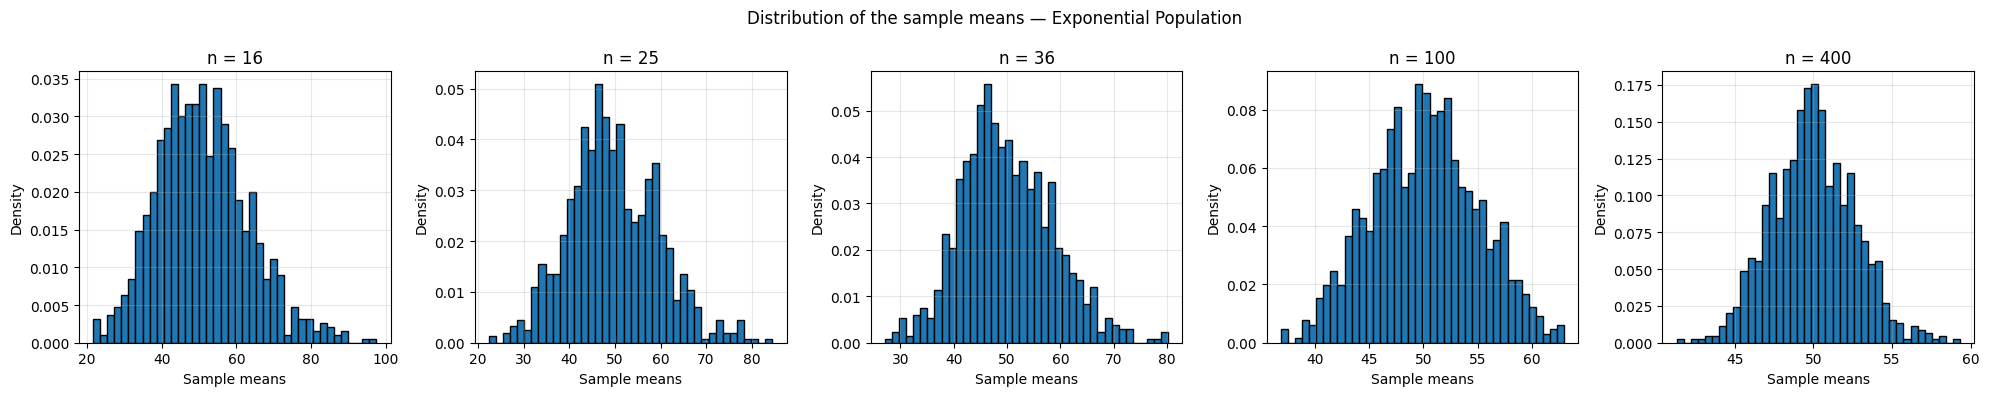

In [20]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    plt.subplot(1, 5, i+1)
    plt.hist(medias_exponenciais[n], bins=40, density=True, edgecolor="black")
    plt.title(f"n = {n}")
    plt.xlabel("Sample means")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribution of the sample means — Exponential Population")
plt.tight_layout()
plt.show()

c-2) On each histogram, overlay the **theoretical normal curve** predicted by the CLT.

Use:

- theoretical mean: `mu`;
- theoretical standard deviation of the means: `sigma / sqrt(n)`.

The theoretical normal curve helps compare the simulated distribution of the means with the approximation predicted by the CLT.

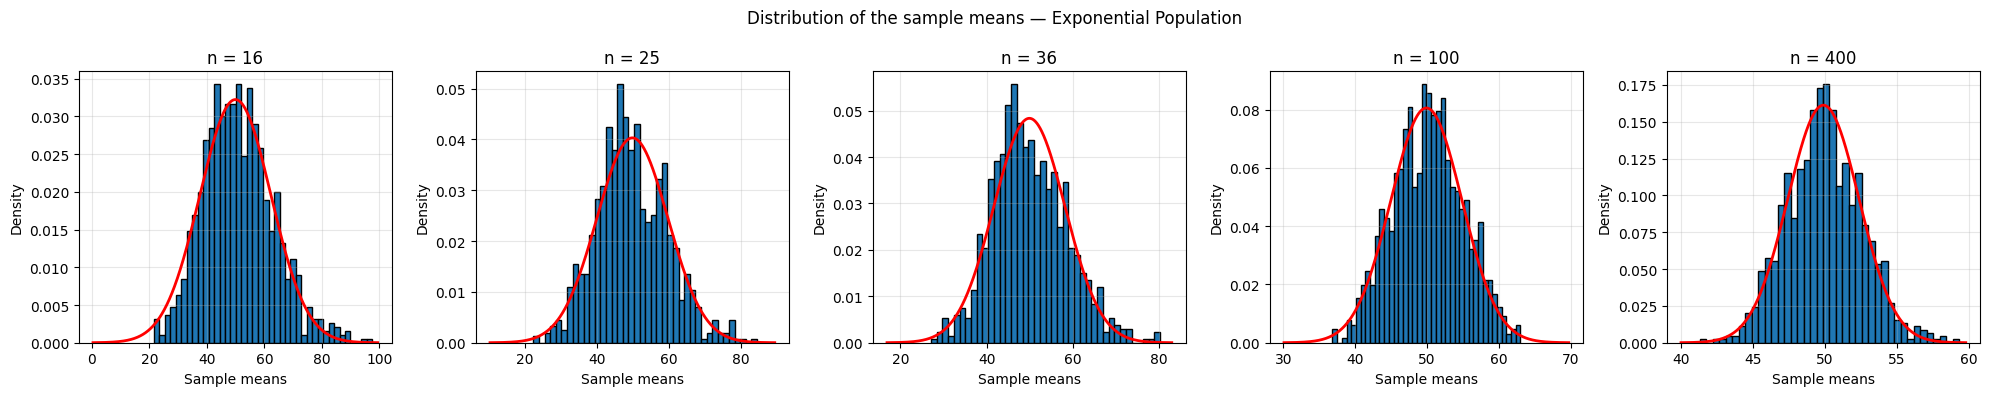

In [21]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    epm_teorico = sigma / np.sqrt(n)
    x = np.linspace(mu - 4*epm_teorico, mu + 4*epm_teorico, 1000)
    y = norm.pdf(x, loc=mu, scale=epm_teorico)

    plt.subplot(1, 5, i+1)
    plt.hist(medias_exponenciais[n], bins=40, density=True, edgecolor="black")
    plt.plot(x, y, color="red", linewidth=2)
    plt.title(f"n = {n}")
    plt.xlabel("Sample means")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribution of the sample means — Exponential Population")
plt.tight_layout()
plt.show()

c-3) Does the distribution of the sample means look normal for every value of `n`?

Answer based on the histograms and the comparison with the theoretical normal curve, commenting especially on what happens as `n` grows.

In [22]:
# Unlike the normal population, for small n (n=16, n=25) the distribution of the means is much more
# skewed — it spreads from roughly 0 to 100, whereas the normal population was far narrower than that
# from the start. On top of that, the theoretical normal curve does not fit the bars well for the
# exponential population, because this population is highly skewed. As n grows (n=100, n=400) the
# distribution of the means becomes more symmetric and concentrated around mu, and the theoretical
# curve fits better and better. This confirms the CLT: even starting from a skewed population, the
# sample means converge to a normal distribution when n is large enough.

c-4) Compute the **mean of the sample means** for each value of `n`, then compare these values with the population mean `mu`.

Build a table with the columns:

| n | mean of means | population mean |
|---|---:|---:|

In [23]:
dados = []

for n in tamanhos_n:
    media_das_medias = round(np.mean(medias_exponenciais[n]), 2)
    dados.append([n, media_das_medias, mu])

tabela = pd.DataFrame(dados, columns=["n", "mean of means", "population mean (exponential)"])
print(tabela)

     n  mean of means  population mean (exponential)
0   16          51.00                           49.9
1   25          49.69                           49.9
2   36          49.92                           49.9
3  100          50.10                           49.9
4  400          49.96                           49.9


c-5) Compute the **observed SEM** and the **theoretical SEM** for each value of `n`.

- observed SEM: standard deviation of the 1000 sample means;
- theoretical SEM: `sigma / sqrt(n)`.

Build a table with the columns:

| n | observed SEM | theoretical SEM |
|---|---:|---:|

This comparison checks whether the simulated behavior is consistent with what the CLT predicts.

In [24]:
dados = []

for n in tamanhos_n:
    epm_obs = round(np.std(medias_exponenciais[n]), 2)
    epm_teo = round(sigma / np.sqrt(n), 2)
    dados.append([n, epm_obs, epm_teo])

tabela_epm = pd.DataFrame(dados, columns=["n", "observed SEM", "theoretical SEM"])
print(tabela_epm)

     n  observed SEM  theoretical SEM
0   16         12.26            12.38
1   25          9.80             9.90
2   36          8.52             8.25
3  100          4.89             4.95
4  400          2.61             2.48


c-6) Plot a chart comparing the **observed SEM** and the **theoretical SEM** as a function of `n`.

The x-axis holds the values of `n`; the y-axis holds the SEM.

The chart shows the drop in the variability of the sample means as the sample size grows.

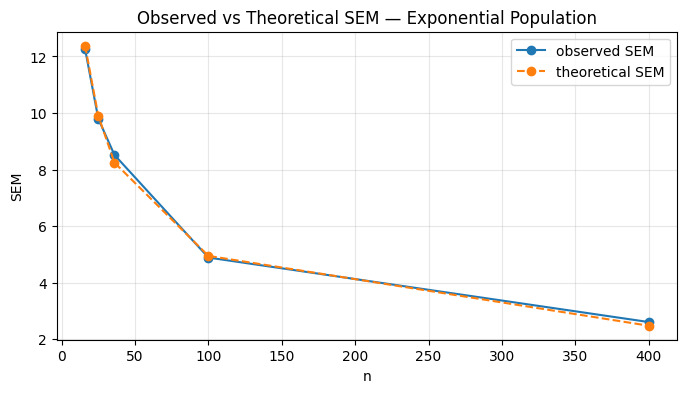

In [25]:
epms_obs = []
epms_teo = []

for n in tamanhos_n:
    epms_obs.append(round(np.std(medias_exponenciais[n]), 2))
    epms_teo.append(round(sigma / np.sqrt(n), 2))

plt.figure(figsize=(8, 4))
plt.plot(tamanhos_n, epms_obs, marker="o", label="observed SEM")
plt.plot(tamanhos_n, epms_teo, marker="o", label="theoretical SEM", linestyle="--")
plt.title("Observed vs Theoretical SEM — Exponential Population")
plt.xlabel("n")
plt.ylabel("SEM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

c-7) Does the standard deviation of the sample means approach the value predicted by the CLT?

Explain using the table and the chart of observed vs theoretical SEM.

In [26]:
# Yes. The chart shows the theoretical SEM tracking the observed SEM almost exactly — proportionally,
# the gap between them was even smaller than for the normal population. This happens because, with
# 1000 samples, the law of large numbers ensures the observed SEM aligns with the theoretical one
# regardless of the shape of the population.

### **Problem 3 — Overall conclusion**

Now I answer the final questions, drawing on the results from the previous problems.

a) Is the distribution of the sample means always normal, or does it depend? Justify using the normal and exponential examples.

In [27]:
# It depends. If the population is already normal, the sample means look normal even for small n.
# If the population is skewed, like the exponential, for small n the means are still far from normal,
# but as n grows they get closer and closer because of the law of large numbers.

b) What happens to the distribution of the sample means as `n` grows? Comment on the shape, the center and the spread.

In [28]:
# As n grows, the distribution of the means becomes narrower and less spread out, getting closer and
# closer to a normal curve. The center stays aligned with the true population mean (mu) for every value of n.

c) What happened to the SEM as `n` grew? Relate your answer to the formula `sigma / sqrt(n)`.

In [29]:
# Increasing n made the SEM tighten around the center. It starts very spread out (around 13 of SEM),
# then compresses, aligning with the theoretical SEM and narrowing toward the true mean. This is
# explained by the formula sigma / sqrt(n): the larger n is, the smaller the SEM.

d) Compare how the CLT behaves on the normal and exponential populations. In which one was the normal approximation more evident for small `n`? Explain.

In [30]:
# The normal approximation was more evident for small values of n in the normal population, because
# that population is already symmetric, so the sample means look normal even for small n. In the
# exponential case, the skewness of the population means a larger n is needed before the means line
# up with a normal distribution.

e) In your own words, explain why the Central Limit Theorem matters for Statistics and Data Science.

In [31]:
# The CLT matters because it guarantees that, regardless of the shape of the population, the larger
# the sample, the closer the distribution of the means gets to a normal. This makes it possible to
# compute, predict and make decisions with more confidence even without knowing the true shape of
# the population.

f) Give a practical real-world example where the CLT helps justify using sample means to make inferences about a population.

In [32]:
# In a college survey, researchers rarely have access to an entire population. With a large enough
# sample, the CLT ensures the sample mean approximates the true population mean, allowing reliable
# inferences without having to collect data from everyone.

## Appendix — Implementation tips

Useful commands that can be adapted:

- `random.choices(population, k=n)` draws a sample with replacement;
- `np.mean(list)` computes the mean;
- `np.std(list, ddof=1)` computes the sample standard deviation;
- `plt.hist(data, density=True)` plots the histogram on a density scale;
- `norm.pdf(x, loc=mean, scale=std)` computes the normal-curve values.

For the theoretical normal curve of the CLT:

```python
media_teorica = mu
epm_teorico = sigma / np.sqrt(n)
```